# Проект модуля (HW-03)

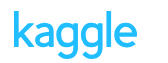

### Corporación Favorita Grocery Sales Forecasting

### Dataset Description

In this competition, you will be predicting the unit sales for thousands of items sold at different Favorita stores located in Ecuador. The training data includes dates, store and item information, whether that item was being promoted, as well as the unit sales. Additional files include supplementary information that may be useful in building your models.

### File Descriptions and Data Field Information

**train.csv**

- Training data, which includes the target unit_sales by date, store_nbr, and item_nbr and a unique id to label rows.
- The target unit_sales can be integer (e.g., a bag of chips) or float (e.g., 1.5 kg of cheese).
- Negative values of unit_sales represent returns of that particular item.
- The onpromotion column tells whether that item_nbr was on promotion for a specified date and store_nbr.
- Approximately 16% of the onpromotion values in this file are NaN.

NOTE: The training data does not include rows for items that had zero unit_sales for a store/date combination. There is no information as to whether or not the item was in stock for the store on the date, and teams will need to decide the best way to handle that situation. Also, there are a small number of items seen in the training data that aren't seen in the test data.

**test.csv**

- Test data, with the date, store_nbr, item_nbr combinations that are to be predicted, along with the onpromotion information.
- NOTE: The test data has a small number of items that are not contained in the training data. Part of the exercise will be to predict a new item sales based on similar products..
- The public / private leaderboard split is based on time. All items in the public split are also included in the private split.

**sample_submission.csv**

- A sample submission file in the correct format.
- It is highly recommend you zip your submission file before uploading!

**stores.csv**

- Store metadata, including city, state, type, and cluster.
- cluster is a grouping of similar stores.

**items.csv**

- Item metadata, including family, class, and perishable.
- NOTE: Items marked as perishable have a score weight of 1.25; otherwise, the weight is 1.0.

**transactions.csv**

- The count of sales transactions for each date, store_nbr combination. Only included for the training data timeframe.

**oil.csv**

- Daily oil price. Includes values during both the train and test data timeframe. (Ecuador is an oil-dependent country and it's economical health is highly vulnerable to shocks in oil prices.)
holidays_events.csv

- Holidays and Events, with metadata
- NOTE: Pay special attention to the transferred column. A holiday that is transferred officially falls on that calendar day, but was moved to another date by the government. A transferred day is more like a normal day than a holiday. To find the day that it was actually celebrated, look for the corresponding row where type is Transfer. For example, the holiday Independencia de Guayaquil was transferred from 2012-10-09 to 2012-10-12, which means it was celebrated on 2012-10-12. Days that are type Bridge are extra days that are added to a holiday (e.g., to extend the break across a long weekend). These are frequently made up by the type Work Day which is a day not normally scheduled for work (e.g., Saturday) that is meant to payback the Bridge.
- Additional holidays are days added a regular calendar holiday, for example, as typically happens around Christmas (making Christmas Eve a holiday).

### Additional Notes
- Wages in the public sector are paid every two weeks on the 15 th and on the last day of the month. Supermarket sales could be affected by this.
- A magnitude 7.8 earthquake struck Ecuador on April 16, 2016. People rallied in relief efforts donating water and other first need products which greatly affected supermarket sales for several weeks after the earthquake.

# 5. Характеристики и параметры временных рядов. Практика

In [ ]:
import pandas as pd
import numpy as np

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from matplotlib import pyplot

from sklearn.model_selection import TimeSeriesSplit


Загрузим данные:

In [30]:
data = pd.read_csv('train/train.csv') # считываем датасет
data.head(3) # смотрим на первые несколько строчек

C:\Users\tgorbunov\AppData\Local\Temp\ipykernel_30960\2765127134.py:1: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('train/train.csv') # считываем датасет


,id,date,store_nbr,item_nbr,unit_sales,onpromotion
0,0,2013-01-01,25,103665,7.0,NaN
1,1,2013-01-01,25,105574,1.0,NaN
2,2,2013-01-01,25,105575,2.0,NaN


Сгруппируeм данные по дате и суммируем количество всех продаж.

In [31]:
df = data[data.store_nbr==25].groupby("date")['unit_sales'].sum().reset_index()
df.head(3)

,date,unit_sales
0,2013-01-01,2511.619
1,2013-01-02,5316.224
2,2013-01-03,4442.913


Приводим индексы к стандарту pd.Datetime, чтобы потом это можно было скормить seasonal_decompose

In [32]:
df = df.set_index(pd.DatetimeIndex(df['date'])) 
df.drop(['date'], axis = 1, inplace = True)
df.head(3)

,unit_sales
date,
2013-01-01,2511.619
2013-01-02,5316.224
2013-01-03,4442.913


Применяем seasonal_decompose

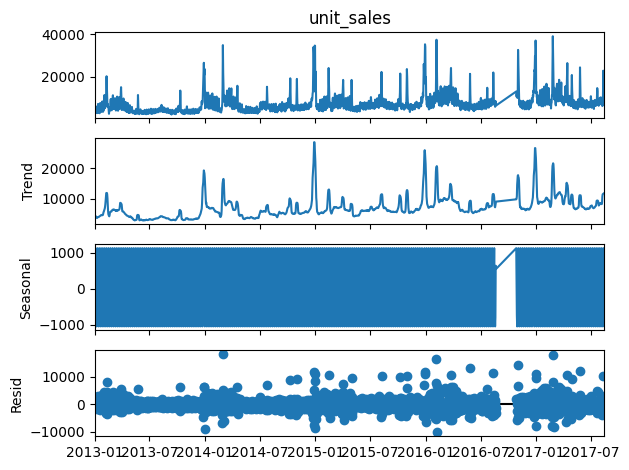

In [33]:
# эта функция разложит ряд на трендовую, сезонную и шумовую составляющие
# задаем период явно (для дневных данных берем недельную сезонность)
decomposition = seasonal_decompose(df['unit_sales'], model='additive', period=7)
decomposition.plot()
pyplot.show() # любуемся результатом

### Задание:

В Jupyter Notebook ответьте на вопросы:

1. Сколько элементов содержит исходный датасет?

2. Сколько элементов содержит шумовая часть?

3. Сколько числовых элементов содержит шумовая часть?

4. Сколько элементов содержит сезонная часть?

5. Сколько числовых элементов содержит трендовая часть?

6. Выполните тест Дики-Фуллера.

In [34]:
# Исходный ряд, который разлагали
original_series = df['unit_sales']

# Компоненты разложения
resid = decomposition.resid
seasonal = decomposition.seasonal
trend = decomposition.trend

# Ответы на вопросы 1-5
print(f"1. Количество элементов в исходном датасете: {len(original_series)}")
print(f"2. Количество элементов в шумовой части: {len(resid)}")
print(f"3. Количество числовых элементов в шумовой части: {resid.notna().sum()}")
print(f"4. Количество элементов в сезонной части: {len(seasonal)}")
print(f"5. Количество числовых элементов в трендовой части: {trend.notna().sum()}")

1. Количество элементов в исходном датасете: 1618
2. Количество элементов в шумовой части: 1618
3. Количество числовых элементов в шумовой части: 1612
4. Количество элементов в сезонной части: 1618
5. Количество числовых элементов в трендовой части: 1612


In [35]:
# 6. Тест Дики-Фуллера
adf_result = adfuller(original_series.dropna())

print("\n6. Тест Дики-Фуллера:")
print(f"ADF-статистика: {adf_result[0]:.6f}")
print(f"p-value: {adf_result[1]:.6f}")
print(f"Количество лагов: {adf_result[2]}")
print(f"Количество наблюдений: {adf_result[3]}")
print("Критические значения:")
for key, value in adf_result[4].items():
    print(f"  {key}: {value:.6f}")

if adf_result[1] < 0.05:
    print("Вывод: ряд стационарен (отвергаем H0 о не стационарности).")
else:
    print("Вывод: ряд нестационарен (нет оснований отвергнуть H0).")


6. Тест Дики-Фуллера:
ADF-статистика: -4.858993
p-value: 0.000042
Количество лагов: 25
Количество наблюдений: 1592
Критические значения:
  1%: -3.434464
  5%: -2.863357
  10%: -2.567737
Вывод: ряд стационарен (отвергаем H0 о не стационарности).


# 6. Особенности валидации временных рядов

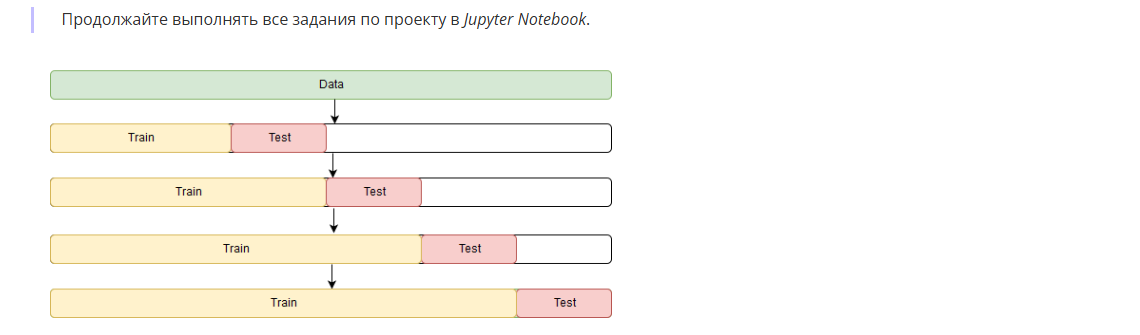

1. Разбейте временной ряд, полученный в предыдущем юните, на три (train + test) набора. Для этого воспользуйтесь TimeSeriesSplit из sklearn.model_selection с параметром n_splits=3 и test_size=7. Наборы данных можно получить, вызвав метод split (временной ряд) у инициализированного TimeSeriesSplit.

2. Выведите размеры полученных подвыборок.

In [37]:
# Берем временной ряд продаж
series = df['unit_sales']

# Разбиение на 3 фолда с тестовым окном 7 наблюдений
tscv = TimeSeriesSplit(n_splits=3, test_size=7)
train_test_groups = tscv.split(series)

for i, (train_index, test_index) in enumerate(train_test_groups, start=1):
    print(f"Split {i}: TRAIN size = {len(train_index)}, TEST size = {len(test_index)}")

Split 1: TRAIN size = 1597, TEST size = 7
Split 2: TRAIN size = 1604, TEST size = 7
Split 3: TRAIN size = 1611, TEST size = 7


# 8. Расчёт факторов при помощи pandas. Практика

Продолжайте выполнять проект в Jupyter Notebook.

1. Выберите временной ряд для одного магазина (можно использовать из прошлого задания).

2. Постройте скользящее среднее c окном 5.

3. Постройте скользящее квадратическое отклонение c окном 5. 

4. Постройте так называемые линии Боллинджера с окном в 30 (если этого позволяет выбранный ряд): добавьте к скользящему среднему скользящее стандартное отклонение, умноженное на три — верхняя линия Боллинджера; отнимите от скользящего среднего скользящее стандартное отклонение, умноженное на три — нижняя линия Боллинджера.

> upper = rolling_mean + 3 * rolling_std
> 
> lower = rolling_mean - 3 * rolling_std

5. Отобразите эти оконные факторы на графике. 

6. Постройте оконное среднее с окном в 10 точек.

7. Постройте экспоненциально среднее с окном в 7 точек (span=7).

8. Отобразите их на отдельном графике. 

9. Напишите свою скользящую функцию, которая будет являться средним арифметическим между максимальным и минимальным значением unit_sales, используя окно 10.

10. Постройте скользящее среднее с окном 50 и экспоненциальное скользящее среднее с окном 10 (span=10). Укажите индексы датафрейма, на которых одно скользящее пересекается с другим. Для этого вычтите из одно скользящего среднего другое, возьмите знак этой разности (np.sign), продифференциируйте его (diff()) и оставьте только те точки, где результат дифференциирования не равен нулю.

11. Получите лаговые факторы с 7-го по 10-й предыдущих дня (лаг7, лаг8, лаг9, лаг10) и отобразите на графике. 